# Lesson 9: Embeddings & Clustering

**Duration:** ~15 minutes  
**Module:** 5 - GDS with Python  
**Dataset:** Cora Citation Network (continued)

## What You'll Learn

- How to scale features for machine learning with `scaleProperties`
- How to create node embeddings with FastRP
- How to cluster papers using K-Means on embeddings
- How to analyze cluster quality and compare to known labels

## What are Node Embeddings?

**The problem:** Machine learning algorithms need fixed-size feature vectors. Graphs have complex, variable structures—a node might have 3 neighbors or 3,000.

**The solution:** Embeddings transform nodes into dense vector representations where:
- Similar nodes get similar vectors
- Graph structure is encoded
- The result is ready for ML algorithms (clustering, classification, link prediction)

**FastRP (Fast Random Projection):**
- Creates embeddings from graph structure + node properties
- Much faster than deep learning approaches (e.g., GraphSAGE, Node2Vec)
- Works well on large graphs (millions of nodes)
- Captures both local and global graph structure

**What influences each paper's embedding?**
1. **Graph structure:** Papers citing similar papers get similar embeddings
2. **Node features:** Papers with similar content (word frequencies) get similar embeddings
3. **Centrality:** We'll include PageRank & Betweenness in our scaled features

## Setup

In [11]:
import os
import pandas as pd
import numpy as np
from IPython.display import display
from graphdatascience import GraphDataScience
from dotenv import load_dotenv
import matplotlib.pyplot as plt
from pprint import pp

# Load credentials from .env
load_dotenv()
uri = os.getenv('NEO4J_URI')
username = os.getenv('NEO4J_USERNAME')
password = os.getenv('NEO4J_PASSWORD')

# Connect to GDS
gds = GraphDataScience(uri, auth=(username, password))

# Clean up any existing ML projection from previous runs
if 'cora-graph-ml' in gds.graph.list()['graphName'].tolist():
    gds.graph.drop('cora-graph-ml')
    print("Dropped existing cora-graph-ml projection")

# Get the base projection from previous lessons
G = gds.graph.get("cora-graph")

print(f"Connected to GDS version: {gds.version()}")
print(f"Graph '{G.name()}' ready: {G.node_count():,} nodes")

Dropped existing cora-graph-ml projection
Connected to GDS version: 2.25.0
Graph 'cora-graph' ready: 2,708 nodes


## Feature Engineering for Machine Learning

Before creating embeddings, we need to scale our features. This is essential because our features have very different ranges.

### Why Scale Features?

**The problem:**
- `features` array: values between 0-1 (word frequencies)
- `betweenness`: values from 0 to thousands
- `pageRank`: values from 0 to ~20

**Without scaling:**
- Algorithms are dominated by high-magnitude features
- `betweenness` would overwhelm `features`

**With scaling:**
- All features normalized to comparable ranges
- Equal contribution to embeddings

### Available Scalers

| Scaler | Output Range | Best For |
|--------|--------------|----------|
| **MinMax** | [0, 1] | Bounded, interpretable values |
| **Max** | [-1, 1] | When preserving sign matters |
| **Mean** | [-1, 1] | When centering around average is useful |
| **Standard** | unbounded | Statistical normalization (z-scores) |
| **Log** | unbounded | Exponential distributions |

We'll use **MinMax** because the bounded [0, 1] output works well with FastRP and is easy to interpret.

### Create a New Projection with All Properties

In [5]:
# Create a new graph projection that includes all properties we want to scale
G2, result = gds.graph.project(
    'cora-graph-ml',
    {
        'Paper': {
            'properties': {
                'features': {'property': 'features'},
                'betweenness': {'property': 'betweenness', 'defaultValue': 0.0},
                'pageRank': {'property': 'pageRank', 'defaultValue': 0.0}
            }
        }
    },
    {
        'CITES': {
            'orientation': 'UNDIRECTED',
            'aggregation': 'SINGLE'
        }
    }
)

print(f"Created projection '{G2.name()}' with {G2.node_count():,} nodes")
print(f"Available properties: {G2.node_properties('Paper')}")

Created projection 'cora-graph-ml' with 2,708 nodes
Available properties: ['features', 'pageRank', 'betweenness']


### Scale and Combine Features

In [6]:
# Scale all features together using GDS scaleProperties
# This combines and normalizes: features (1433-dim) + betweenness + pageRank
scaled_result = gds.scaleProperties.mutate(
    G2,
    nodeProperties=['features', 'betweenness', 'pageRank'],
    scaler='MinMax',
    mutateProperty='scaledFeatures'
)

print(f"Scaled properties for {scaled_result['nodePropertiesWritten']:,} papers")
print(f"\nScaler Statistics:")
print(f"  Betweenness - min: {scaled_result['scalerStatistics']['betweenness']['min'][0]:.2f}, max: {scaled_result['scalerStatistics']['betweenness']['max'][0]:.2f}")
print(f"  PageRank - min: {scaled_result['scalerStatistics']['pageRank']['min'][0]:.2f}, max: {scaled_result['scalerStatistics']['pageRank']['max'][0]:.2f}")
print(f"  Features - {len(scaled_result['scalerStatistics']['features']['min'])} dimensions scaled")

Scaled properties for 2,708 papers

Scaler Statistics:
  Betweenness - min: 0.00, max: 850663.01
  PageRank - min: 0.29, max: 32.67
  Features - 1433 dimensions scaled


**What just happened?**

We used `gds.scaleProperties.mutate()` to:
1. Combine three feature types: content features (1,433-dim) + betweenness + pageRank
2. Normalize using MinMax scaling (all values now in [0,1] range)
3. Store as a single property: `scaledFeatures`

The result is a 1,435-dimensional feature vector for each paper, ready for FastRP.

## Creating Embeddings with FastRP

Now we'll use FastRP to create 128-dimensional embeddings that combine:
- **Content features** (1,433 word frequencies)
- **Centrality metrics** (PageRank + Betweenness)
- **Graph structure** (citation patterns)

All compressed into 128 dimensions.

In [7]:
# Run FastRP to create 128-dimensional embeddings
fastrp_result = gds.fastRP.mutate(
    G2,
    mutateProperty='embedding',
    embeddingDimension=128,
    featureProperties=['scaledFeatures'],
    randomSeed=42,
    iterationWeights=[0.0, 1.0, 1.0]
)

print(f"Created {fastrp_result['nodePropertiesWritten']:,} embeddings")
print(f"  Embedding dimension: 128")
print(f"  Input features: 1,435 dimensions (scaledFeatures)")

Created 2,708 embeddings
  Embedding dimension: 128
  Input features: 1,435 dimensions (scaledFeatures)


**What just happened?**

FastRP created a 128-dimensional vector for each paper by:
1. Initializing random vectors for each node
2. Propagating information along citation edges (controlled by `iterationWeights`)
3. Combining propagated vectors with our `scaledFeatures`
4. Projecting to 128 dimensions using random projection

**Understanding `iterationWeights=[0.0, 1.0, 1.0]`:**
- Iteration 0 (weight 0.0): Self-information, ignored
- Iteration 1 (weight 1.0): 1-hop neighbors (papers that cite or are cited by this paper)
- Iteration 2 (weight 1.0): 2-hop neighbors (papers connected through one intermediate paper)

More iterations capture longer-range structure in the graph.

## Clustering Papers with K-Means

Now we'll use the embeddings to cluster papers into research topics.

**Why K-Means on embeddings?**

Compare with Louvain from Lesson 8:

| Aspect | Louvain | K-Means on Embeddings |
|--------|---------|----------------------|
| Input | Graph structure only | Structure + content + centrality |
| Method | Modularity optimization | Distance in embedding space |
| Clusters | Found automatically | You specify k |
| Best for | Finding natural communities | Comparing to known categories |

We have 7 official subject categories, so we'll use k=7 and compare the results.

In [8]:
# Run K-Means clustering on the embeddings
kmeans_result = gds.kmeans.write(
    G2,
    nodeProperty='embedding',
    k=7,
    writeProperty='kmeans7_cluster',
    randomSeed=42,
    maxIterations=100
)

print(f"Clustered {kmeans_result['nodePropertiesWritten']:,} papers into 7 clusters")
print(f"  Computation time: {kmeans_result['computeMillis']:,}ms")
print(f"\nCluster size distribution:")
print(f"  Min: {kmeans_result['communityDistribution']['min']}")
print(f"  Max: {kmeans_result['communityDistribution']['max']}")
print(f"  Mean: {kmeans_result['communityDistribution']['mean']:.1f}")

Clustered 2,708 papers into 7 clusters
  Computation time: 24ms

Cluster size distribution:
  Min: 9
  Max: 1382
  Mean: 386.9


### How K-Means Works

Imagine you have 2,708 papers scattered across a room, where papers on similar topics are placed closer together. K-Means finds 7 "center points" (centroids) such that each paper is closest to the center of its own group.

**The algorithm:**

1. **Initialize:** Place 7 random centroids in embedding space
2. **Assign:** Each paper joins the cluster whose centroid is closest
3. **Update:** Each cluster recalculates its centroid as the mean of all members
4. **Repeat:** Continue until papers stop switching clusters (convergence)

**Why does this work?**

Our embeddings encode similarity: papers that cite similar work, use similar words, and have similar influence end up with similar 128-dimensional vectors. K-Means groups papers whose vectors are close together.

## Analyzing Clusters

Let's see how the K-Means clusters relate to the actual paper subjects.

In [12]:
# Compare K-Means clusters with official subjects
q_cluster_analysis = """
MATCH (p:Paper)
WHERE p.kmeans7_cluster IS NOT NULL
RETURN 
    p.kmeans7_cluster AS cluster,
    p.subject AS subject,
    count(*) AS count
ORDER BY cluster, count DESC
LIMIT 30
"""

df_clusters = gds.run_cypher(q_cluster_analysis)
print("K-Means Cluster Composition by Subject:")
print("=" * 60)
pp(df_clusters)

K-Means Cluster Composition by Subject:
    cluster                 subject  count
0         0         Neural_Networks      9
1         0      Genetic_Algorithms      2
2         1      Genetic_Algorithms    336
3         1         Neural_Networks    173
4         1              Case_Based    100
5         1                  Theory     99
6         1   Probabilistic_Methods     87
7         1           Rule_Learning     30
8         1  Reinforcement_Learning     22
9         2      Genetic_Algorithms      8
10        2              Case_Based      1
11        3         Neural_Networks    173
12        3           Rule_Learning     67
13        3              Case_Based     37
14        3  Reinforcement_Learning     29
15        3                  Theory     28
16        3   Probabilistic_Methods     11
17        3      Genetic_Algorithms     10
18        4         Neural_Networks    384
19        4   Probabilistic_Methods    306
20        4                  Theory    224
21        4  R

In [15]:
# Pivot to see cluster purity
pivot = df_clusters.pivot(index='cluster', columns='subject', values='count').fillna(0)
pp("Cluster composition matrix:")
pp(pivot)

# Calculate dominant subject per cluster
pp("\nCluster purity analysis:")
for cluster in pivot.index:
    dominant = pivot.loc[cluster].idxmax()
    purity = pivot.loc[cluster].max() / pivot.loc[cluster].sum() * 100
    pp(f"  Cluster {cluster}: {dominant} ({purity:.1f}% pure)")

'Cluster composition matrix:'
subject  Case_Based  Genetic_Algorithms  Neural_Networks  \
cluster                                                    
0               0.0                 2.0              9.0   
1             100.0               336.0            173.0   
2               1.0                 8.0              0.0   
3              37.0                10.0            173.0   
4             160.0                60.0            384.0   
5               0.0                 2.0             74.0   
6               0.0                 0.0              0.0   

subject  Probabilistic_Methods  Reinforcement_Learning  Rule_Learning  Theory  
cluster                                                                        
0                          0.0                     0.0            0.0     0.0  
1                         87.0                    22.0           30.0    99.0  
2                          0.0                     0.0            0.0     0.0  
3                         11.

**Interpreting the results:**

- **Pure clusters (>70%):** Tightly focused research areas that align with official subjects
- **Mixed clusters (<50%):** Interdisciplinary areas that span multiple subjects
- **Mismatches:** May reveal research groupings not captured by formal labels

This is powerful because clusters emerge from citation patterns AND content AND centrality—not just the labels humans assigned.

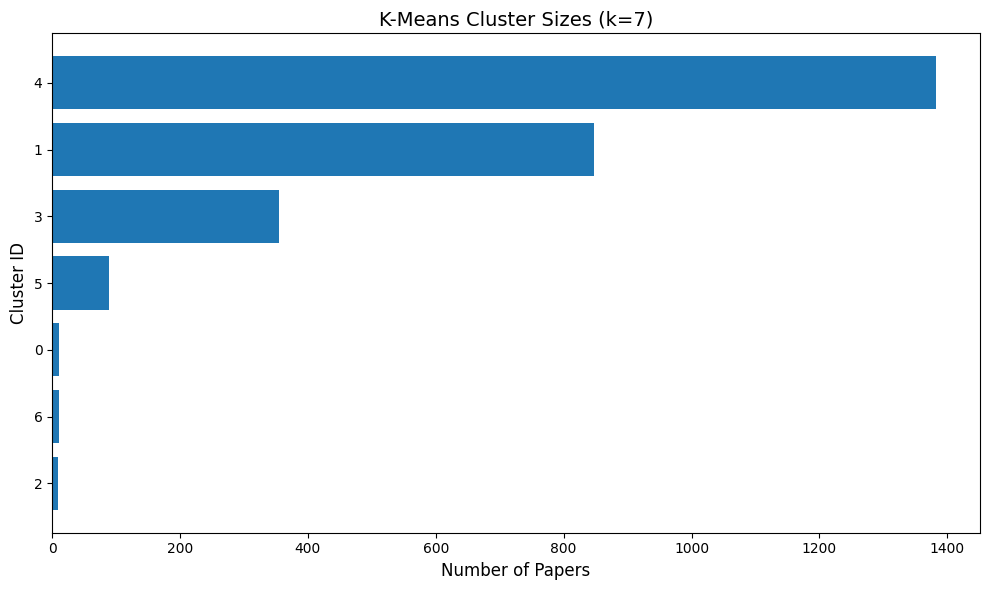

In [16]:
# Visualize cluster sizes
cluster_sizes = df_clusters.groupby('cluster')['count'].sum().sort_values(ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(cluster_sizes.index.astype(str), cluster_sizes.values)
plt.xlabel('Number of Papers', fontsize=12)
plt.ylabel('Cluster ID', fontsize=12)
plt.title('K-Means Cluster Sizes (k=7)', fontsize=14)
plt.tight_layout()
plt.show()

## Cleanup

In [17]:
# Drop projections
G.drop()
G2.drop()
print("Dropped graph projections")

# Close the connection
gds.close()
print("Connection closed")

Dropped graph projections
Connection closed


## Summary

In this lesson, you:

- Scaled features with `scaleProperties` to bring all values to comparable ranges
- Created 128-dimensional embeddings with FastRP combining structure, content, and centrality
- Clustered papers with K-Means and compared clusters to official subject labels
- Analyzed cluster purity to understand how well embeddings capture meaningful structure

### Module 5 Complete

You've completed the entire Python GDS workflow on citation networks.

| Lesson | Topic | Key Algorithms |
|--------|-------|----------------|
| 5 | Citation Network Setup | Data loading, projections |
| 6 | Influential Papers | PageRank |
| 7 | Bridge Papers | Betweenness Centrality |
| 8 | Research Communities | Louvain |
| 9 | Embeddings & Clustering | scaleProperties, FastRP, K-Means |

### Key Takeaways

1. **Combine multiple algorithms** for richer insights than any single metric provides
2. **Scale features** before using them in ML algorithms
3. **Structure + Content + Centrality** creates powerful embeddings
4. **Compare algorithmic results to known labels** to validate your approach

### Transfer from Module 2

The same algorithms work across domains:

| Algorithm | Fraud Detection (Module 2) | Citation Networks (Module 5) |
|-----------|---------------------------|------------------------------|
| PageRank | Find influential fraudsters | Find influential papers |
| Betweenness | Find fraud ring connectors | Find interdisciplinary bridges |
| Louvain | Detect fraud communities | Detect research communities |